<a href="https://colab.research.google.com/github/MarioSigal/Aprendizaje-Automatico/blob/main/Analisis%20Exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Exploratorio

In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import os
import skimage
from PIL import Image

In [36]:
drive.mount('/content/drive')
ruta ="/content/drive/MyDrive/Fotos_Ax10_18-02-2026/004_003.tiff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


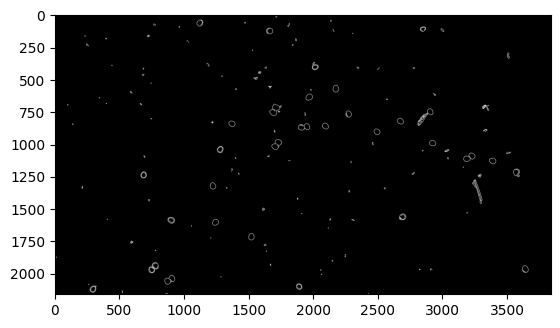

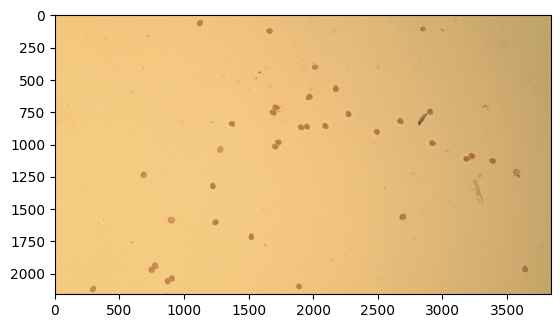

In [37]:
im = Image.open(ruta)
im_gris = skimage.color.rgb2gray(im)
im_bordes = skimage.feature.canny(im_gris)
plt.imshow(im)
plt.imshow(im_gris)
plt.imshow(im_bordes,cmap='gray')

im_bin = im_bordes.astype(np.uint8)
def BinarizarImagen(imagen, umbral=0):
  imgB = imagen.copy()
  imgB[imgB<=umbral] = 0
  imgB[imgB>umbral] = 255
  return imgB




im_bin = BinarizarImagen(im_bin)

from skimage.morphology import dilation, disk

def agrandar_bordes(imagen, radio=1):
    return dilation(imagen, disk(radio))

im_big = agrandar_bordes(im_bin)
plt.imshow(im_big,cmap='gray')
plt.show()
plt.imshow(im,cmap='gray')
plt.show()

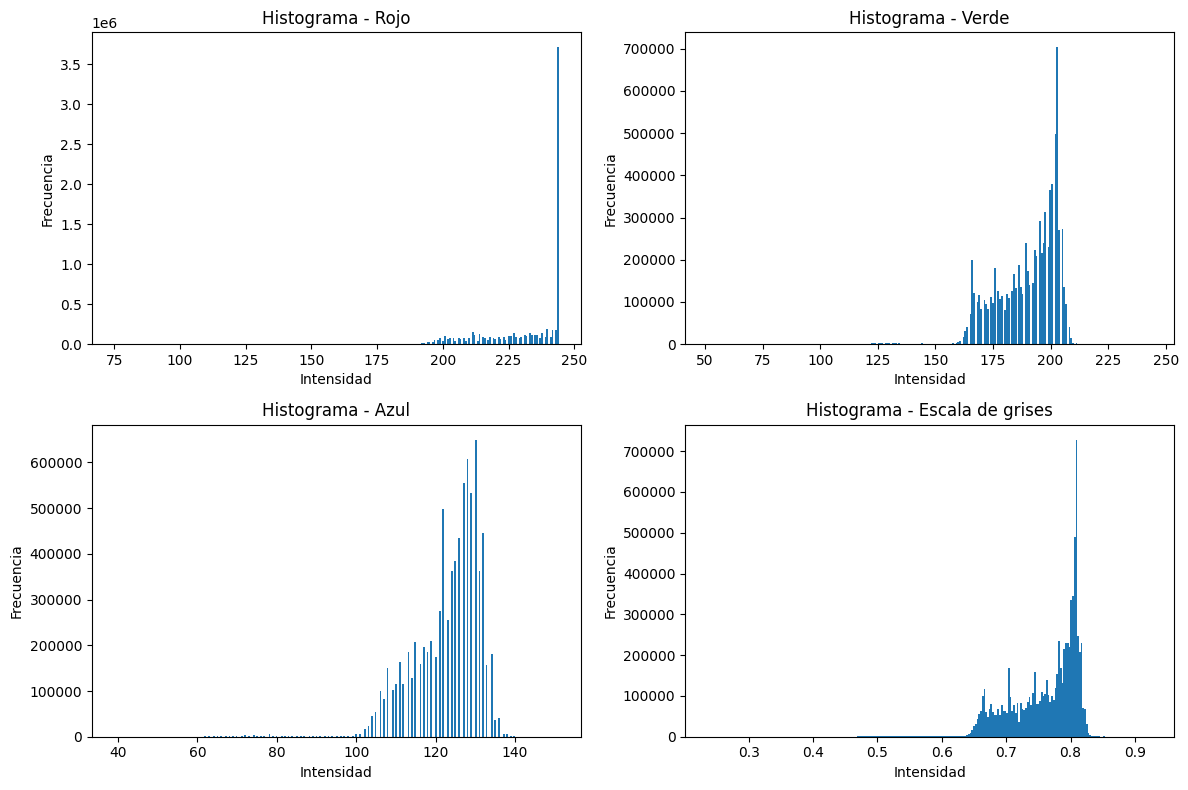

In [38]:
import numpy as np
import matplotlib.pyplot as plt

im_array = np.array(im)

# Canales RGB
r = im_array[:, :, 0]
g = im_array[:, :, 1]
b = im_array[:, :, 2]

# Imagen en gris
gris = skimage.color.rgb2gray(im_array)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Rojo
axs[0, 0].hist(r.ravel(), bins=256)
axs[0, 0].set_title("Histograma - Rojo")
axs[0, 0].set_xlabel("Intensidad")
axs[0, 0].set_ylabel("Frecuencia")

# Verde
axs[0, 1].hist(g.ravel(), bins=256)
axs[0, 1].set_title("Histograma - Verde")
axs[0, 1].set_xlabel("Intensidad")
axs[0, 1].set_ylabel("Frecuencia")

# Azul
axs[1, 0].hist(b.ravel(), bins=256)
axs[1, 0].set_title("Histograma - Azul")
axs[1, 0].set_xlabel("Intensidad")
axs[1, 0].set_ylabel("Frecuencia")

# Gris
axs[1, 1].hist(gris.ravel(), bins=256)
axs[1, 1].set_title("Histograma - Escala de grises")
axs[1, 1].set_xlabel("Intensidad")
axs[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

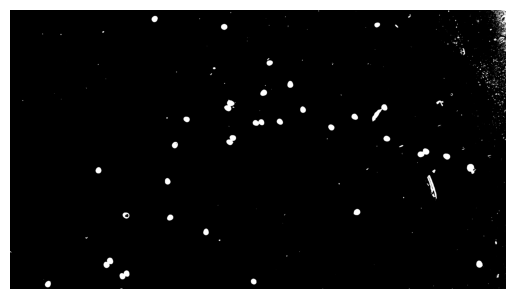

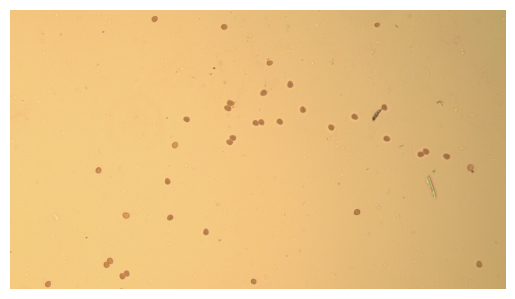

In [68]:
import numpy as np
import matplotlib.pyplot as plt

im_array = np.array(im)

# Canal rojo
r = im_array[:, :, 0]
g = im_array[:, :, 1]
b = im_array[:, :, 2]

# Binarización
im_bin = np.where((r > 190) & (g>160), 0, 255).astype(np.uint8)

plt.imshow(im_bin, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(im)
plt.axis('off')
plt.show()